# Deep Learning Assignment - Nonlinear Regression Variants

**Goal:** Build a 3-hidden-layer neural network for nonlinear regression using synthetic data with **3 input variables**.

**Synthetic equation used in this notebook**

\[
y = \sin(x_1) + 0.5x_2^2 - 0.3x_3^3 + 0.2x_1x_2 - 0.1x_2x_3 + \epsilon
\]

where \(\epsilon\) is small Gaussian noise.

## What this notebook demonstrates
- 3-input nonlinear synthetic data generation
- train/validation split
- 3-hidden-layer neural network
- loss tracking across epochs
- final output comparison
- a **4D-style plot** using 3D coordinates + color for the target value
- clean section-wise code organization for video walkthrough

> You can narrate this notebook section by section during the assignment demo.


## Variant A - Numpy-style neural network from scratch with manual backprop

This notebook implements a neural network **from scratch** with:
- manual parameter initialization
- manual forward propagation
- manual chain-rule-based backpropagation
- gradient descent updates

### Important note for the assignment
Even though this is a "numpy-style" from-scratch notebook, the professor note asked to use **`tensorflow.einsum`** instead of regular matrix multiplication.  
So this notebook uses:
- NumPy for data handling
- TensorFlow `einsum` for layer computations
- manual gradients and updates written explicitly

In [1]:
!pip -q install tensorflow scikit-learn matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

def make_data(n_samples=1800, noise=0.08):
    x1 = np.random.uniform(-3, 3, n_samples)
    x2 = np.random.uniform(-2, 2, n_samples)
    x3 = np.random.uniform(-1.5, 1.5, n_samples)

    y = (
        np.sin(x1)
        + 0.5 * (x2 ** 2)
        - 0.3 * (x3 ** 3)
        + 0.2 * x1 * x2
        - 0.1 * x2 * x3
        + np.random.normal(0, noise, n_samples)
    )

    X = np.column_stack([x1, x2, x3]).astype(np.float32)
    y = y.reshape(-1, 1).astype(np.float32)
    return X, y

X, y = make_data()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1260, 3) (1260, 1)
Val  : (270, 3) (270, 1)
Test : (270, 3) (270, 1)


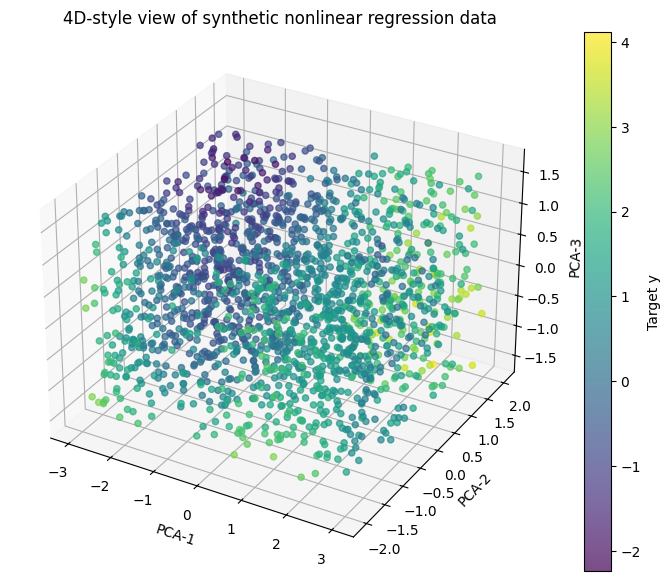

In [3]:
# 4D-style plot:
# - 3D position = PCA projection of the 3 input variables
# - color = target value y

pca = PCA(n_components=3)
X_vis = pca.fit_transform(X)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], X_vis[:, 2], c=y.flatten(), alpha=0.7)
ax.set_title("4D-style view of synthetic nonlinear regression data")
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
ax.set_zlabel("PCA-3")
fig.colorbar(scatter, ax=ax, label="Target y")
plt.show()

## Activation functions and helper utilities

We use:
- **ReLU** in hidden layers
- **Linear output** for regression
- **Mean Squared Error** as the loss function

In [4]:
import tensorflow as tf

tf.random.set_seed(SEED)

def relu(x):
    return tf.maximum(0.0, x)

def relu_grad(x):
    return tf.cast(x > 0, tf.float32)

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

## Manual 3-hidden-layer network definition

Architecture:
- Input: 3
- Hidden-1: 32
- Hidden-2: 24
- Hidden-3: 16
- Output: 1

All weights and biases are created manually.

In [5]:
input_dim = 3
h1, h2, h3 = 32, 24, 16
output_dim = 1

def init_params():
    params = {
        "W1": tf.Variable(tf.random.normal([input_dim, h1], stddev=0.15)),
        "b1": tf.Variable(tf.zeros([1, h1])),
        "W2": tf.Variable(tf.random.normal([h1, h2], stddev=0.15)),
        "b2": tf.Variable(tf.zeros([1, h2])),
        "W3": tf.Variable(tf.random.normal([h2, h3], stddev=0.15)),
        "b3": tf.Variable(tf.zeros([1, h3])),
        "W4": tf.Variable(tf.random.normal([h3, output_dim], stddev=0.15)),
        "b4": tf.Variable(tf.zeros([1, output_dim])),
    }
    return params

params = init_params()

## Forward propagation using `tf.einsum`

Instead of:
- `X @ W`

we use:
- `tf.einsum('bi,ij->bj', X, W)`

This satisfies the assignment note about using Einstein summation notation.

In [6]:
def forward_pass(X_batch, params):
    z1 = tf.einsum('bi,ij->bj', X_batch, params["W1"]) + params["b1"]
    a1 = relu(z1)

    z2 = tf.einsum('bi,ij->bj', a1, params["W2"]) + params["b2"]
    a2 = relu(z2)

    z3 = tf.einsum('bi,ij->bj', a2, params["W3"]) + params["b3"]
    a3 = relu(z3)

    z4 = tf.einsum('bi,ij->bj', a3, params["W4"]) + params["b4"]
    y_hat = z4  # linear output

    cache = {
        "X": X_batch, "z1": z1, "a1": a1,
        "z2": z2, "a2": a2,
        "z3": z3, "a3": a3,
        "z4": z4, "y_hat": y_hat
    }
    return y_hat, cache

## Manual backpropagation

This section explicitly applies the **chain rule** layer by layer.  
No autograd is used here.

In [7]:
def backward_pass(y_true, params, cache):
    m = tf.cast(tf.shape(y_true)[0], tf.float32)

    Xb = cache["X"]
    z1, a1 = cache["z1"], cache["a1"]
    z2, a2 = cache["z2"], cache["a2"]
    z3, a3 = cache["z3"], cache["a3"]
    y_hat = cache["y_hat"]

    # dL/dy_hat for MSE = 2*(y_hat - y)/m
    dZ4 = 2.0 * (y_hat - y_true) / m
    dW4 = tf.einsum('bi,bj->ij', a3, dZ4)
    db4 = tf.reduce_sum(dZ4, axis=0, keepdims=True)

    dA3 = tf.einsum('bi,ji->bj', dZ4, params["W4"])
    dZ3 = dA3 * relu_grad(z3)
    dW3 = tf.einsum('bi,bj->ij', a2, dZ3)
    db3 = tf.reduce_sum(dZ3, axis=0, keepdims=True)

    dA2 = tf.einsum('bi,ji->bj', dZ3, params["W3"])
    dZ2 = dA2 * relu_grad(z2)
    dW2 = tf.einsum('bi,bj->ij', a1, dZ2)
    db2 = tf.reduce_sum(dZ2, axis=0, keepdims=True)

    dA1 = tf.einsum('bi,ji->bj', dZ2, params["W2"])
    dZ1 = dA1 * relu_grad(z1)
    dW1 = tf.einsum('bi,bj->ij', Xb, dZ1)
    db1 = tf.reduce_sum(dZ1, axis=0, keepdims=True)

    grads = {
        "W1": dW1, "b1": db1,
        "W2": dW2, "b2": db2,
        "W3": dW3, "b3": db3,
        "W4": dW4, "b4": db4
    }
    return grads

In [8]:
def update_params(params, grads, lr=0.01):
    for key in params:
        params[key].assign_sub(lr * grads[key])

def predict_numpy_style(X_input, params):
    X_tf = tf.convert_to_tensor(X_input, dtype=tf.float32)
    y_hat, _ = forward_pass(X_tf, params)
    return y_hat.numpy()

## Training loop

We train using full-batch gradient descent so the math remains easy to explain in the video.

In [9]:
X_train_tf = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)
X_val_tf = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val_tf = tf.convert_to_tensor(y_val, dtype=tf.float32)

epochs = 700
lr = 0.01

train_losses = []
val_losses = []

params = init_params()

for epoch in range(epochs):
    train_pred, cache = forward_pass(X_train_tf, params)
    train_loss = mse_loss(y_train_tf, train_pred)

    grads = backward_pass(y_train_tf, params, cache)
    update_params(params, grads, lr=lr)

    val_pred, _ = forward_pass(X_val_tf, params)
    val_loss = mse_loss(y_val_tf, val_pred)

    train_losses.append(float(train_loss.numpy()))
    val_losses.append(float(val_loss.numpy()))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_losses[-1]:.6f}")

Epoch 100 | Train Loss: 0.934742 | Val Loss: 1.056949
Epoch 200 | Train Loss: 0.603725 | Val Loss: 0.722016
Epoch 300 | Train Loss: 0.470303 | Val Loss: 0.587791
Epoch 400 | Train Loss: 0.360105 | Val Loss: 0.449723
Epoch 500 | Train Loss: 0.264703 | Val Loss: 0.325620
Epoch 600 | Train Loss: 0.193550 | Val Loss: 0.233219
Epoch 700 | Train Loss: 0.155821 | Val Loss: 0.184230


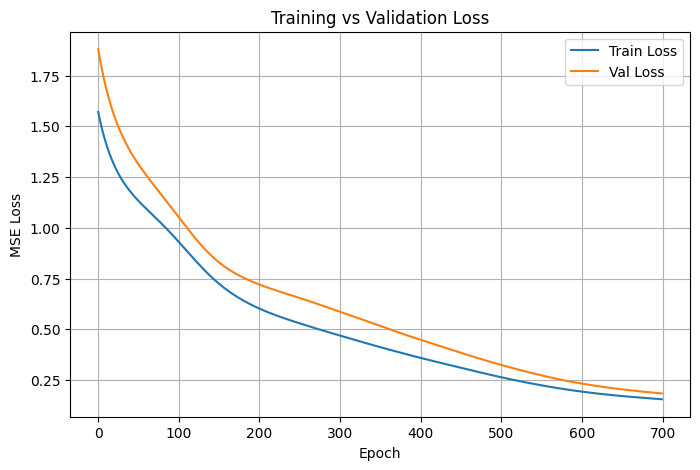

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

## Final evaluation and output samples

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def regression_report(y_true, y_pred, label="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{label} Regression Report")
    print("-" * 40)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

In [16]:
y_test_pred = predict_numpy_style(X_test, params)

regression_report(y_test, y_test_pred, label="Numpy-style Manual Network")

sample_idx = np.random.choice(len(X_test), size=10, replace=False)
print("\nSample predictions:")
for idx in sample_idx:
    print(f"Input: {X_test[idx]} | True: {y_test[idx,0]:.4f} | Pred: {y_test_pred[idx,0]:.4f}")


Numpy-style Manual Network Regression Report
----------------------------------------
RMSE: 0.4299
MAE : 0.3234
R2  : 0.8550

Sample predictions:
Input: [ 1.1702113  -0.45760962  1.3766156 ] | True: 0.2377 | Pred: 0.2430
Input: [ 0.39842784  0.00241428 -1.0856241 ] | True: 0.9169 | Pred: 0.5991
Input: [-1.6323891  1.1767893 -0.3824732] | True: -0.6830 | Pred: -0.2297
Input: [-2.8541043 -1.3950127 -1.1440687] | True: 1.6799 | Pred: 1.1271
Input: [-2.6899097   1.6603602  -0.20609488] | True: 0.0138 | Pred: -0.2949
Input: [-1.2333066  -0.16679743 -0.24699901] | True: -0.9353 | Pred: -0.4757
Input: [-1.8027453   0.97152597  1.2286454 ] | True: -1.5183 | Pred: -1.1458
Input: [ 2.3560302  1.2286222 -0.643122 ] | True: 2.1877 | Pred: 2.3462
Input: [-1.5455416  -0.45383796  1.2240556 ] | True: -1.3622 | Pred: -0.6032
Input: [-0.30932686 -0.7809956  -0.7205156 ] | True: 0.1933 | Pred: 0.6052


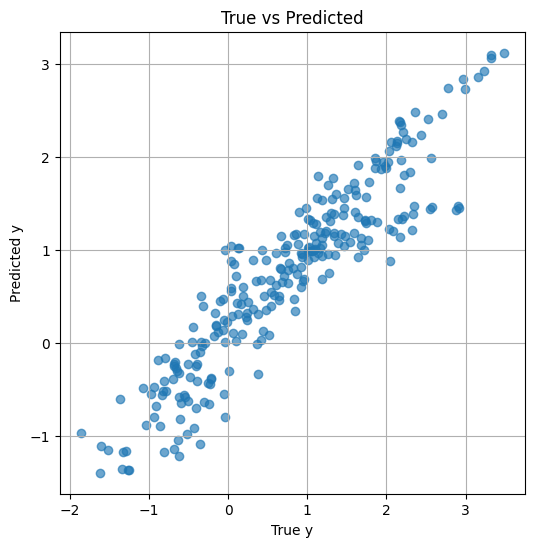

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.65)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("True vs Predicted")
plt.grid(True)
plt.show()

## What to say in the demo
- Explain the synthetic nonlinear equation with 3 variables
- Show the PCA-based 4D-style plot
- Explain how each weight and bias is created manually
- Point out the use of `tf.einsum` instead of matrix multiplication
- Walk through forward pass -> loss -> backprop -> parameter update
- Show the loss graph and final sample predictions